📂 Working directory : C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main
🖼️  Images found      : ['a.png']
✅ Image loaded: C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\a.png  |  size: 603x405
⚠️  No face detected — using full image as ROI.

✅ Predicted Emotion : happy
   Confidence        : 97.37%
   Probabilities     → happy=0.974 | sad=0.025 | angry=0.001
   Bounding Box      → x=0, y=0, w=603, h=405


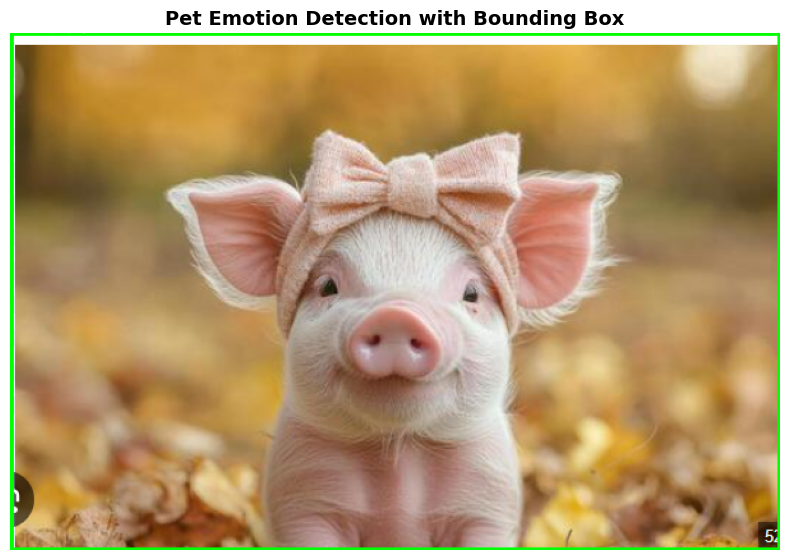


💾 Result saved to: C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_with_bbox.png


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
import os

# ─── Load Model ───────────────────────────────────────────────────────────────
loaded_model = load_model(
    "Pet_facial_emotion_model.h5",
    compile=False
)
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Emotion classes & colors
emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 255, 0), 'sad': (255, 0, 0), 'angry': (0, 0, 255)}

# ─── Helper: robust image loader ──────────────────────────────────────────────
def load_image_robust(image_path):
    abs_path = os.path.abspath(image_path)

    # ✅ Show current working directory & available images to help debug
    cwd = os.getcwd()
    available = [f for f in os.listdir(cwd) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"📂 Working directory : {cwd}")
    print(f"🖼️  Images found      : {available}")

    if not os.path.exists(abs_path):
        raise FileNotFoundError(
            f"\n❌ Image not found: {abs_path}"
            f"\n   Make sure '{image_path}' is in: {cwd}"
            f"\n   Available images: {available}"
        )

    pil_img = Image.open(abs_path).convert("RGB")
    img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    print(f"✅ Image loaded: {abs_path}  |  size: {img_bgr.shape[1]}x{img_bgr.shape[0]}")
    return img_bgr

# ─── Main prediction function ─────────────────────────────────────────────────
def predict_with_bounding_box(image_path):

    # 1. Load image
    original_img = load_image_robust(image_path)
    display_img  = original_img.copy()
    gray         = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

    # 2. Detect face/pet region
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        print("⚠️  No face detected — using full image as ROI.")
        h, w  = original_img.shape[:2]
        faces = [(0, 0, w, h)]

    # 3. Predict each detected region
    for (x, y, w, h) in faces:
        roi            = original_img[y:y+h, x:x+w]
        roi_resized    = cv2.resize(roi, (128, 128))
        roi_normalized = roi_resized.astype('float32') / 255.0
        roi_input      = np.expand_dims(roi_normalized, axis=0)  # (1, 128, 128, 3)

        prediction        = loaded_model.predict(roi_input, verbose=0)
        prediction_prob   = prediction[0]
        emotion_label     = np.argmax(prediction_prob)
        predicted_emotion = emotion_classes[emotion_label]
        confidence        = prediction_prob[emotion_label] * 100

        # 4. Draw bounding box & label
        color = emotion_colors[predicted_emotion]
        cv2.rectangle(display_img, (x, y), (x+w, y+h), color, 3)

        label = f"{predicted_emotion}  {confidence:.1f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(display_img, (x, y - th - 14), (x + tw + 6, y), color, -1)
        cv2.putText(display_img, label, (x + 3, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        # 5. Console output
        print(f"\n✅ Predicted Emotion : {predicted_emotion}")
        print(f"   Confidence        : {confidence:.2f}%")
        print(f"   Probabilities     → happy={prediction_prob[0]:.3f} | "
              f"sad={prediction_prob[1]:.3f} | angry={prediction_prob[2]:.3f}")
        print(f"   Bounding Box      → x={x}, y={y}, w={w}, h={h}")

    # 6. Display result
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(display_rgb)
    plt.title("Pet Emotion Detection with Bounding Box", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img

# ─── Run ──────────────────────────────────────────────────────────────────────
# ✅ Use just the filename if the image is in the same folder as this script
# OR provide the full Windows path, e.g: r"C:\Users\YourName\Desktop\a.png"
custom_test_image_path = "a.png"

result_image = predict_with_bounding_box(custom_test_image_path)

# Save result to same folder
output_path = "predicted_with_bbox.png"
cv2.imwrite(output_path, result_image)
print(f"\n💾 Result saved to: {os.path.abspath(output_path)}")

✅ ANGRY  |  confidence: 62.8%  |  box → x=300 y=240 w=69 h=69


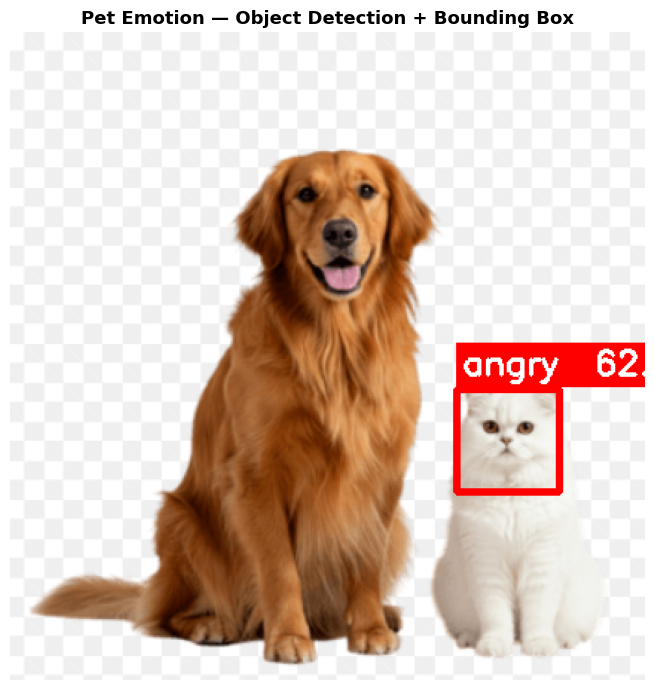

💾 Saved → C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_with_bbox.png


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
import os

# ─── Load Model ───────────────────────────────────────────────────────────────
loaded_model = load_model("Pet_facial_emotion_model.h5", compile=False)
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 255, 0), 'sad': (255, 0, 0), 'angry': (0, 0, 255)}

# ─── Load all cascades ─────────────────────────────────────────────────────────
cascades = [
    cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'),
    cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalcatface.xml'),
    cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalcatface_extended.xml'),
    cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_fullbody.xml'),
]

# ─── Fixed detect_objects ──────────────────────────────────────────────────────
def detect_objects(gray_img):
    best_faces = []
    best_area  = 0                                          # ✅ track area separately

    for cascade in cascades:
        detected = cascade.detectMultiScale(
            gray_img, scaleFactor=1.05, minNeighbors=3, minSize=(40, 40)
        )
        if len(detected) > 0:
            area = sum(int(w) * int(h) for (_, _, w, h) in detected)   # ✅ explicit int cast
            if area > best_area:                                         # ✅ clean comparison
                best_faces = detected
                best_area  = area

    return best_faces

# ─── Main function ─────────────────────────────────────────────────────────────
def predict_with_bounding_box(image_path):

    # Load image
    abs_path = os.path.abspath(image_path)
    if not os.path.exists(abs_path):
        available = [f for f in os.listdir('.') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        raise FileNotFoundError(f"❌ Not found: {abs_path}\n   Available images: {available}")

    pil_img      = Image.open(abs_path).convert("RGB")
    original_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    display_img  = original_img.copy()
    gray         = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

    # Detect
    detections = detect_objects(gray)

    if len(detections) == 0:
        print("⚠️  No object detected — using full image as ROI.")
        h, w       = original_img.shape[:2]
        detections = [(0, 0, w, h)]

    # Predict & draw
    for (x, y, w, h) in detections:
        roi       = original_img[y:y+h, x:x+w]
        roi_input = np.expand_dims(cv2.resize(roi, (128, 128)).astype('float32') / 255.0, axis=0)

        prediction        = loaded_model.predict(roi_input, verbose=0)
        prediction_prob   = prediction[0]
        emotion_label     = np.argmax(prediction_prob)
        predicted_emotion = emotion_classes[emotion_label]
        confidence        = prediction_prob[emotion_label] * 100
        color             = emotion_colors[predicted_emotion]

        # Bounding box
        cv2.rectangle(display_img, (x, y), (x+w, y+h), color, 3)

        # Label tag
        label       = f"{predicted_emotion}  {confidence:.1f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.75, 2)
        tag_y       = max(y - th - 14, 0)
        cv2.rectangle(display_img, (x, tag_y), (x + tw + 8, tag_y + th + 12), color, -1)
        cv2.putText(display_img, label, (x + 4, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)

        print(f"✅ {predicted_emotion.upper()}  |  confidence: {confidence:.1f}%  |  "
              f"box → x={x} y={y} w={w} h={h}")

    # Show
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(9, 7))
    plt.imshow(display_rgb)
    plt.title("Pet Emotion — Object Detection + Bounding Box", fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img

# ─── Run ──────────────────────────────────────────────────────────────────────
result = predict_with_bounding_box("b.png")
cv2.imwrite("predicted_with_bbox.png", result)
print(f"💾 Saved → {os.path.abspath('predicted_with_bbox.png')}")

📂 Working directory : C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main
🖼️  Images found      : ['a.png']
✅ Image loaded: C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\a.png  |  size: 603x405
⚠️  No face detected — using full image as ROI.

✅ Predicted Emotion : happy
   Confidence        : 97.37%
   Probabilities     → happy=0.974 | sad=0.025 | angry=0.001
   Bounding Box      → x=0, y=0, w=603, h=405


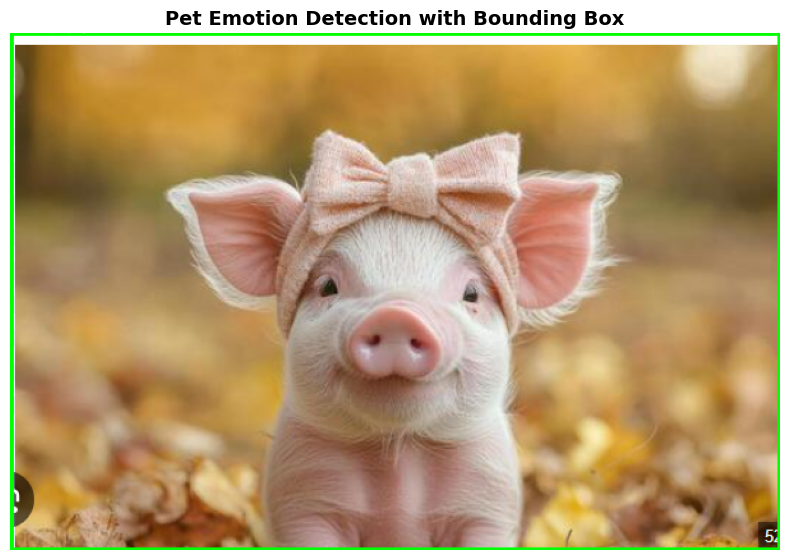


💾 Result saved to: C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_with_bbox.png


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
import os

# ─── Load Model ───────────────────────────────────────────────────────────────
loaded_model = load_model(
    "Pet_facial_emotion_model.h5",
    compile=False
)
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Emotion classes & colors
emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 255, 0), 'sad': (255, 0, 0), 'angry': (0, 0, 255)}

# ─── Helper: robust image loader ──────────────────────────────────────────────
def load_image_robust(image_path):
    abs_path = os.path.abspath(image_path)

    # ✅ Show current working directory & available images to help debug
    cwd = os.getcwd()
    available = [f for f in os.listdir(cwd) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"📂 Working directory : {cwd}")
    print(f"🖼️  Images found      : {available}")

    if not os.path.exists(abs_path):
        raise FileNotFoundError(
            f"\n❌ Image not found: {abs_path}"
            f"\n   Make sure '{image_path}' is in: {cwd}"
            f"\n   Available images: {available}"
        )

    pil_img = Image.open(abs_path).convert("RGB")
    img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    print(f"✅ Image loaded: {abs_path}  |  size: {img_bgr.shape[1]}x{img_bgr.shape[0]}")
    return img_bgr

# ─── Main prediction function ─────────────────────────────────────────────────
def predict_with_bounding_box(image_path):

    # 1. Load image
    original_img = load_image_robust(image_path)
    display_img  = original_img.copy()
    gray         = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

    # 2. Detect face/pet region
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        print("⚠️  No face detected — using full image as ROI.")
        h, w  = original_img.shape[:2]
        faces = [(0, 0, w, h)]

    # 3. Predict each detected region
    for (x, y, w, h) in faces:
        roi            = original_img[y:y+h, x:x+w]
        roi_resized    = cv2.resize(roi, (128, 128))
        roi_normalized = roi_resized.astype('float32') / 255.0
        roi_input      = np.expand_dims(roi_normalized, axis=0)  # (1, 128, 128, 3)

        prediction        = loaded_model.predict(roi_input, verbose=0)
        prediction_prob   = prediction[0]
        emotion_label     = np.argmax(prediction_prob)
        predicted_emotion = emotion_classes[emotion_label]
        confidence        = prediction_prob[emotion_label] * 100

        # 4. Draw bounding box & label
        color = emotion_colors[predicted_emotion]
        cv2.rectangle(display_img, (x, y), (x+w, y+h), color, 3)

        label = f"{predicted_emotion}  {confidence:.1f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(display_img, (x, y - th - 14), (x + tw + 6, y), color, -1)
        cv2.putText(display_img, label, (x + 3, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        # 5. Console output
        print(f"\n✅ Predicted Emotion : {predicted_emotion}")
        print(f"   Confidence        : {confidence:.2f}%")
        print(f"   Probabilities     → happy={prediction_prob[0]:.3f} | "
              f"sad={prediction_prob[1]:.3f} | angry={prediction_prob[2]:.3f}")
        print(f"   Bounding Box      → x={x}, y={y}, w={w}, h={h}")

    # 6. Display result
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(display_rgb)
    plt.title("Pet Emotion Detection with Bounding Box", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img

# ─── Run ──────────────────────────────────────────────────────────────────────
# ✅ Use just the filename if the image is in the same folder as this script
# OR provide the full Windows path, e.g: r"C:\Users\YourName\Desktop\a.png"
custom_test_image_path = "a.png"

result_image = predict_with_bounding_box(custom_test_image_path)

# Save result to same folder
output_path = "predicted_with_bbox.png"
cv2.imwrite(output_path, result_image)
print(f"\n💾 Result saved to: {os.path.abspath(output_path)}")

In [8]:
# ─── Step 1: Install dependencies ─────────────────────────────────────────────
# Run this once in your terminal / Jupyter cell:
# pip install ultralytics keras tensorflow opencv-python pillow matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
from ultralytics import YOLO
import os

# ─── Load Models ──────────────────────────────────────────────────────────────
# YOLOv8 — auto-downloads yolov8n.pt on first run (~6MB)
yolo_model = YOLO("yolov8n.pt")

# Your emotion classifier
emotion_model = load_model("Pet_facial_emotion_model.h5", compile=False)
emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ─── Config ───────────────────────────────────────────────────────────────────
emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 200, 0), 'sad': (255, 80, 80), 'angry': (0, 0, 255)}

# COCO animal class IDs that YOLOv8 can detect
ANIMAL_CLASS_IDS = {
    15: 'bird',  16: 'cat',   17: 'dog',   18: 'horse',
    19: 'sheep', 20: 'cow',   21: 'elephant', 22: 'bear',
    23: 'zebra', 24: 'giraffe'
}

# ─── Main ─────────────────────────────────────────────────────────────────────
def predict_all_animals(image_path, confidence_threshold=0.35):

    # Load image
    abs_path = os.path.abspath(image_path)
    if not os.path.exists(abs_path):
        available = [f for f in os.listdir('.') if f.lower().endswith(('.png','.jpg','.jpeg'))]
        raise FileNotFoundError(f"❌ Not found: {abs_path}\n   Available: {available}")

    pil_img      = Image.open(abs_path).convert("RGB")
    original_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    display_img  = original_img.copy()

    # ── YOLO Detection ────────────────────────────────────────────────────────
    results      = yolo_model(original_img, verbose=False)[0]
    animal_count = 0

    print(f"\n{'─'*55}")
    print(f"  🐾 Multi-Animal Emotion Detection")
    print(f"{'─'*55}")

    for det in results.boxes:
        cls_id     = int(det.cls[0])
        yolo_conf  = float(det.conf[0])

        # Skip non-animal detections
        if cls_id not in ANIMAL_CLASS_IDS:
            continue
        if yolo_conf < confidence_threshold:
            continue

        animal_count += 1
        animal_name  = ANIMAL_CLASS_IDS[cls_id]

        # Bounding box coords
        x1, y1, x2, y2 = map(int, det.xyxy[0])
        x1, y1 = max(0, x1), max(0, y1)
        x2      = min(original_img.shape[1], x2)
        y2      = min(original_img.shape[0], y2)
        w, h    = x2 - x1, y2 - y1

        # Skip too-small detections
        if w < 20 or h < 20:
            continue

        # ── Emotion Prediction on cropped animal ─────────────────────────────
        roi       = original_img[y1:y2, x1:x2]
        roi_input = np.expand_dims(
            cv2.resize(roi, (128, 128)).astype('float32') / 255.0, axis=0
        )

        emotion_pred      = emotion_model.predict(roi_input, verbose=0)[0]
        emotion_label     = np.argmax(emotion_pred)
        predicted_emotion = emotion_classes[emotion_label]
        emo_confidence    = emotion_pred[emotion_label] * 100
        color             = emotion_colors[predicted_emotion]

        # ── Draw bounding box ─────────────────────────────────────────────────
        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, 3)

        # ── Draw label tag ────────────────────────────────────────────────────
        label       = f"{animal_name} | {predicted_emotion} {emo_confidence:.0f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        tag_y       = max(y1 - th - 14, 0)
        cv2.rectangle(display_img, (x1, tag_y), (x1 + tw + 10, tag_y + th + 12), color, -1)
        cv2.putText(display_img, label, (x1 + 5, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        # ── Console log ───────────────────────────────────────────────────────
        print(f"  #{animal_count} {animal_name.upper():<10} "
              f"emotion: {predicted_emotion:<6}  "
              f"confidence: {emo_confidence:.1f}%  "
              f"(YOLO: {yolo_conf:.2f})")
        print(f"      probs → happy={emotion_pred[0]:.2f}  "
              f"sad={emotion_pred[1]:.2f}  angry={emotion_pred[2]:.2f}")

    # ── Summary watermark ─────────────────────────────────────────────────────
    summary = f"Animals detected: {animal_count}"
    cv2.putText(display_img, summary, (10, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3)

    print(f"{'─'*55}")
    print(f"  ✅ Total animals detected: {animal_count}")
    print(f"{'─'*55}\n")

    if animal_count == 0:
        print("⚠️  No animals found. Try lowering confidence_threshold (e.g. 0.2)")

    # ── Display ───────────────────────────────────────────────────────────────
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 10))
    plt.imshow(display_rgb)
    plt.title(f"Multi-Animal Emotion Detection  —  {animal_count} animal(s) found",
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img

# ─── Run ──────────────────────────────────────────────────────────────────────
result = predict_all_animals("a.png", confidence_threshold=0.35)
cv2.imwrite("predicted_all_animals.png", result)
print(f"💾 Saved → {os.path.abspath('predicted_all_animals.png')}")

ModuleNotFoundError: No module named 'ultralytics'

In [1]:
# ─── Cell 1: Install ultralytics ──────────────────────────────────────────────
!pip install ultralytics -q

In [10]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 4.2 MB/s eta 0:00:01
   ----------------------------------- ---- 1.6/1.8 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 3.9 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ─── Cell 2: Verify install ───────────────────────────────────────────────────
import ultralytics
ultralytics.checks()

Ultralytics 8.4.23  Python-3.12.7 torch-2.10.0+cpu CPU (Intel Core i7-7500U 2.70GHz)
Setup complete  (4 CPUs, 15.9 GB RAM, 97.6/119.1 GB disk)



───────────────────────────────────────────────────────
  🐾 Multi-Animal Emotion Detection
───────────────────────────────────────────────────────
  #1 CAT        emotion: sad     confidence: 99.9%  (YOLO: 0.91)
      probs → happy=0.00  sad=1.00  angry=0.00
  #2 BIRD       emotion: sad     confidence: 100.0%  (YOLO: 0.87)
      probs → happy=0.00  sad=1.00  angry=0.00
───────────────────────────────────────────────────────
  ✅ Total animals detected: 2
───────────────────────────────────────────────────────



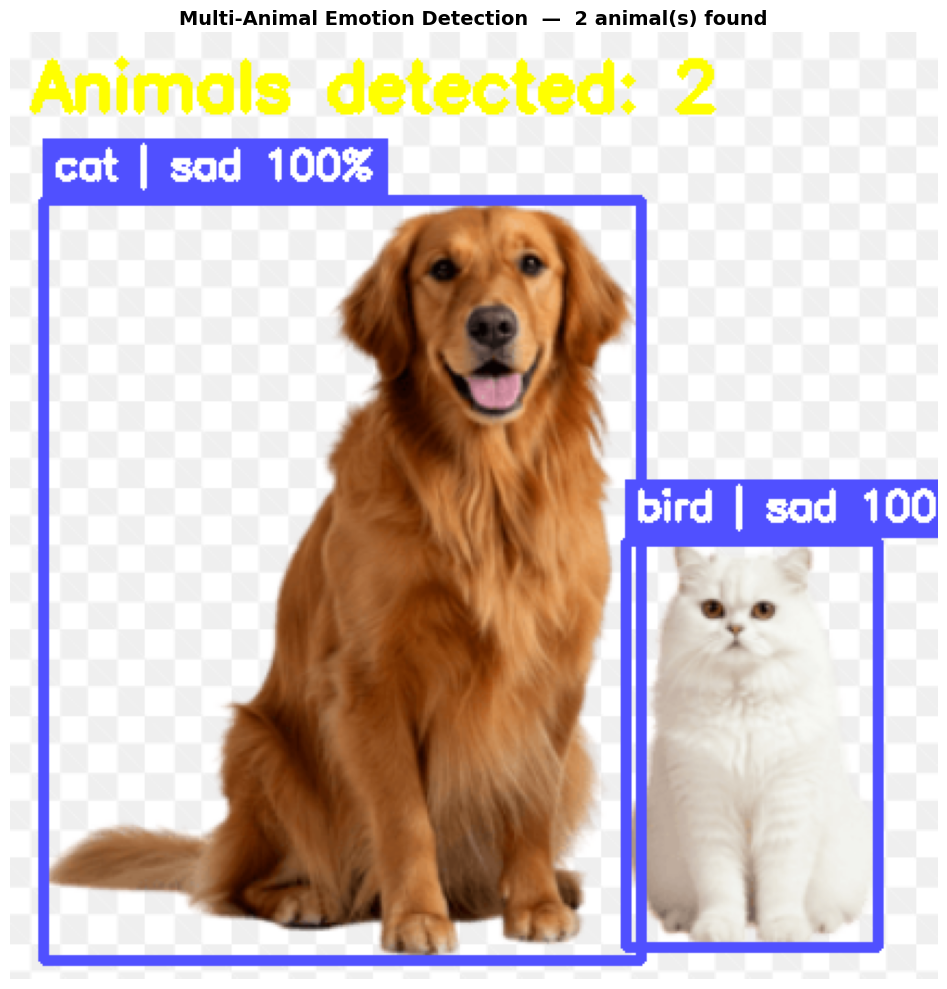

💾 Saved → C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_all_animals.png


In [4]:
# ─── Cell 3: Full Code ────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
from ultralytics import YOLO
import os

# ─── Load Models ──────────────────────────────────────────────────────────────
yolo_model    = YOLO("yolov8n.pt")   # auto-downloads on first run
emotion_model = load_model("Pet_facial_emotion_model.h5", compile=False)
emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 200, 0), 'sad': (255, 80, 80), 'angry': (0, 0, 255)}

ANIMAL_CLASS_IDS = {
    15: 'bird',  16: 'cat',   17: 'dog',   18: 'horse',
    19: 'sheep', 20: 'cow',   21: 'elephant', 22: 'bear',
    23: 'zebra', 24: 'giraffe'
}

def predict_all_animals(image_path, confidence_threshold=0.35):

    abs_path = os.path.abspath(image_path)
    if not os.path.exists(abs_path):
        available = [f for f in os.listdir('.') if f.lower().endswith(('.png','.jpg','.jpeg'))]
        raise FileNotFoundError(f"❌ Not found: {abs_path}\n   Available: {available}")

    pil_img      = Image.open(abs_path).convert("RGB")
    original_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    display_img  = original_img.copy()

    results      = yolo_model(original_img, verbose=False)[0]
    animal_count = 0

    print(f"\n{'─'*55}")
    print(f"  🐾 Multi-Animal Emotion Detection")
    print(f"{'─'*55}")

    for det in results.boxes:
        cls_id    = int(det.cls[0])
        yolo_conf = float(det.conf[0])

        if cls_id not in ANIMAL_CLASS_IDS or yolo_conf < confidence_threshold:
            continue

        animal_count += 1
        animal_name   = ANIMAL_CLASS_IDS[cls_id]

        x1, y1, x2, y2 = map(int, det.xyxy[0])
        x1, y1 = max(0, x1), max(0, y1)
        x2      = min(original_img.shape[1], x2)
        y2      = min(original_img.shape[0], y2)
        w, h    = x2 - x1, y2 - y1

        if w < 20 or h < 20:
            continue

        roi       = original_img[y1:y2, x1:x2]
        roi_input = np.expand_dims(
            cv2.resize(roi, (128, 128)).astype('float32') / 255.0, axis=0
        )

        emotion_pred      = emotion_model.predict(roi_input, verbose=0)[0]
        emotion_label     = np.argmax(emotion_pred)
        predicted_emotion = emotion_classes[emotion_label]
        emo_confidence    = emotion_pred[emotion_label] * 100
        color             = emotion_colors[predicted_emotion]

        # Bounding box
        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, 3)

        # Label
        label       = f"{animal_name} | {predicted_emotion} {emo_confidence:.0f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        tag_y       = max(y1 - th - 14, 0)
        cv2.rectangle(display_img, (x1, tag_y), (x1 + tw + 10, tag_y + th + 12), color, -1)
        cv2.putText(display_img, label, (x1 + 5, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        print(f"  #{animal_count} {animal_name.upper():<10} "
              f"emotion: {predicted_emotion:<6}  confidence: {emo_confidence:.1f}%  "
              f"(YOLO: {yolo_conf:.2f})")
        print(f"      probs → happy={emotion_pred[0]:.2f}  "
              f"sad={emotion_pred[1]:.2f}  angry={emotion_pred[2]:.2f}")

    # Summary
    summary = f"Animals detected: {animal_count}"
    cv2.putText(display_img, summary, (10, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3)

    print(f"{'─'*55}")
    print(f"  ✅ Total animals detected: {animal_count}")
    print(f"{'─'*55}\n")

    if animal_count == 0:
        print("⚠️  No animals found. Try lowering confidence_threshold to 0.2")

    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 10))
    plt.imshow(display_rgb)
    plt.title(f"Multi-Animal Emotion Detection  —  {animal_count} animal(s) found",
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img

# ─── Run ──────────────────────────────────────────────────────────────────────
result = predict_all_animals("b.png", confidence_threshold=0.35)
cv2.imwrite("predicted_all_animals.png", result)
print(f"💾 Saved → {os.path.abspath('predicted_all_animals.png')}")


────────────────────────────────────────────────────────────
  🔍 ALL YOLO detections (including non-animals):
     class_id= 16  name=dog              conf=0.94
────────────────────────────────────────────────────────────

  🐾 Filtered Animal Predictions:
────────────────────────────────────────────────────────────
  #1 DOG          emotion: happy   conf: 98.2%  (YOLO conf: 0.94)
       probs → happy=0.98  sad=0.02  angry=0.00
────────────────────────────────────────────────────────────
  ✅ Total animals: 1
────────────────────────────────────────────────────────────



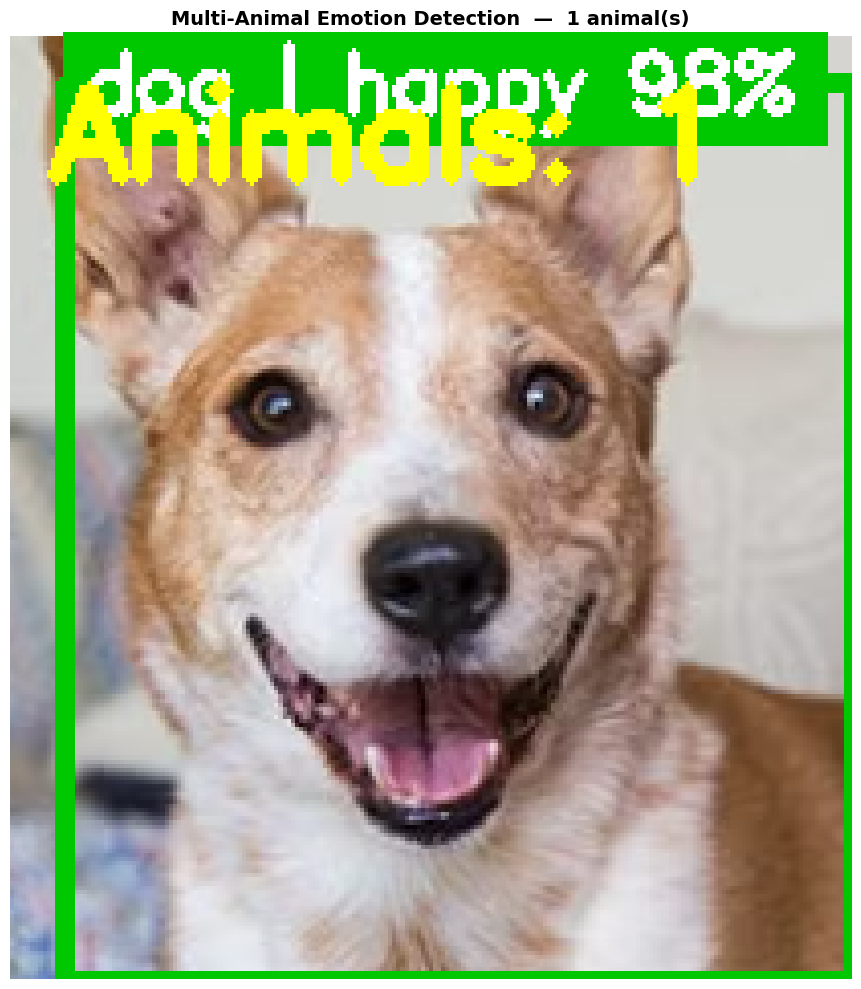

💾 Saved → C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_all_animals.png


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
from ultralytics import YOLO
import os

# ─── Load Models ──────────────────────────────────────────────────────────────
yolo_model    = YOLO("yolov8n.pt")
emotion_model = load_model("Pet_facial_emotion_model.h5", compile=False)
emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 200, 0), 'sad': (255, 80, 80), 'angry': (0, 0, 255)}

ANIMAL_CLASS_IDS = {
    15: 'bird',  16: 'cat',  17: 'dog',   18: 'horse',
    19: 'sheep', 20: 'cow',  21: 'elephant', 22: 'bear',
    23: 'zebra', 24: 'giraffe'
}

# ─── Crop FACE from detected animal bounding box ──────────────────────────────
# Emotion model trained on faces — feed only top 40% of bounding box (head region)
def crop_face_region(img, x1, y1, x2, y2):
    h = y2 - y1
    w = x2 - x1

    # Top 40% of bounding box = head/face area
    face_y2 = y1 + int(h * 0.45)

    # Slight horizontal crop to center face
    pad_x   = int(w * 0.1)
    face_x1 = min(x1 + pad_x, x2)
    face_x2 = max(x2 - pad_x, x1)

    # Safety clamp
    face_x1 = max(0, face_x1)
    face_y1 = max(0, y1)
    face_x2 = min(img.shape[1], face_x2)
    face_y2 = min(img.shape[0], face_y2)

    face_roi = img[face_y1:face_y2, face_x1:face_x2]

    # Fallback to full box if crop is too small
    if face_roi.shape[0] < 10 or face_roi.shape[1] < 10:
        face_roi = img[y1:y2, x1:x2]

    return face_roi

# ─── Main ─────────────────────────────────────────────────────────────────────
def predict_all_animals(image_path, confidence_threshold=0.35):

    abs_path = os.path.abspath(image_path)
    if not os.path.exists(abs_path):
        available = [f for f in os.listdir('.') if f.lower().endswith(('.png','.jpg','.jpeg'))]
        raise FileNotFoundError(f"❌ Not found: {abs_path}\n   Available: {available}")

    # ── Load & convert image ──────────────────────────────────────────────────
    pil_img      = Image.open(abs_path).convert("RGB")   # strips alpha/transparency
    original_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    display_img  = original_img.copy()

    # ── YOLO detection ────────────────────────────────────────────────────────
    results = yolo_model(original_img, verbose=False)[0]

    # Debug: print ALL detections so you can see what YOLO found
    print(f"\n{'─'*60}")
    print(f"  🔍 ALL YOLO detections (including non-animals):")
    for d in results.boxes:
        cid  = int(d.cls[0])
        cname = yolo_model.names[cid]     # ✅ use YOLO's own name dict
        conf  = float(d.conf[0])
        print(f"     class_id={cid:3d}  name={cname:<15}  conf={conf:.2f}")
    print(f"{'─'*60}")

    animal_count = 0
    print(f"\n  🐾 Filtered Animal Predictions:")
    print(f"{'─'*60}")

    for det in results.boxes:
        cls_id    = int(det.cls[0])
        yolo_conf = float(det.conf[0])

        if cls_id not in ANIMAL_CLASS_IDS or yolo_conf < confidence_threshold:
            continue

        animal_count += 1
        # ✅ Always use YOLO's own name — never trust hardcoded dict alone
        animal_name = yolo_model.names[cls_id]

        x1, y1, x2, y2 = map(int, det.xyxy[0])
        x1 = max(0, x1);  y1 = max(0, y1)
        x2 = min(original_img.shape[1], x2)
        y2 = min(original_img.shape[0], y2)

        if (x2 - x1) < 20 or (y2 - y1) < 20:
            continue

        # ✅ Feed only FACE region to emotion model (not full body)
        face_roi  = crop_face_region(original_img, x1, y1, x2, y2)
        roi_input = np.expand_dims(
            cv2.resize(face_roi, (128, 128)).astype('float32') / 255.0, axis=0
        )

        emotion_pred      = emotion_model.predict(roi_input, verbose=0)[0]
        emotion_label     = np.argmax(emotion_pred)
        predicted_emotion = emotion_classes[emotion_label]
        emo_conf          = emotion_pred[emotion_label] * 100
        color             = emotion_colors[predicted_emotion]

        # ── Draw full bounding box ────────────────────────────────────────────
        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, 3)

        # ── Label tag ─────────────────────────────────────────────────────────
        label       = f"{animal_name} | {predicted_emotion} {emo_conf:.0f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        tag_y       = max(y1 - th - 14, 0)
        cv2.rectangle(display_img, (x1, tag_y), (x1 + tw + 10, tag_y + th + 12), color, -1)
        cv2.putText(display_img, label, (x1 + 5, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

        print(f"  #{animal_count} {animal_name.upper():<12} "
              f"emotion: {predicted_emotion:<6}  conf: {emo_conf:.1f}%  "
              f"(YOLO conf: {yolo_conf:.2f})")
        print(f"       probs → happy={emotion_pred[0]:.2f}  "
              f"sad={emotion_pred[1]:.2f}  angry={emotion_pred[2]:.2f}")

    # ── Summary ───────────────────────────────────────────────────────────────
    cv2.putText(display_img, f"Animals: {animal_count}", (10, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3)

    print(f"{'─'*60}")
    print(f"  ✅ Total animals: {animal_count}")
    if animal_count == 0:
        print("  ⚠️  Try lowering confidence_threshold to 0.2")
    print(f"{'─'*60}\n")

    # ── Show ──────────────────────────────────────────────────────────────────
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 10))
    plt.imshow(display_rgb)
    plt.title(f"Multi-Animal Emotion Detection  —  {animal_count} animal(s)",
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img

# ─── Run ──────────────────────────────────────────────────────────────────────
result = predict_all_animals("j.png", confidence_threshold=0.35)
cv2.imwrite("predicted_all_animals.png", result)
print(f"💾 Saved → {os.path.abspath('predicted_all_animals.png')}")


  📐 Output image size: 207x233 px

────────────────────────────────────────────────────────────
  🔍 ALL YOLO detections (including non-animals):
     class_id= 16  name=dog              conf=0.94
────────────────────────────────────────────────────────────

  🐾 Filtered Animal Predictions:
────────────────────────────────────────────────────────────
  #1 DOG          emotion: happy   conf: 98.2%  (YOLO conf: 0.94)
       probs → happy=0.98  sad=0.02  angry=0.00
────────────────────────────────────────────────────────────
  ✅ Total animals: 1
────────────────────────────────────────────────────────────



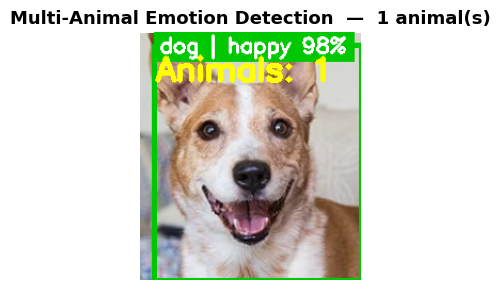

💾 Saved → C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_cnn.jpg
📦 File size: 43.6 KB


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
from ultralytics import YOLO
import os

# ─── Load Models ──────────────────────────────────────────────────────────────
yolo_model    = YOLO("yolov8n.pt")
emotion_model = load_model("Pet_facial_emotion_model.h5", compile=False)
emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 200, 0), 'sad': (255, 80, 80), 'angry': (0, 0, 255)}

ANIMAL_CLASS_IDS = {
    15: 'bird',  16: 'cat',  17: 'dog',   18: 'horse',
    19: 'sheep', 20: 'cow',  21: 'elephant', 22: 'bear',
    23: 'zebra', 24: 'giraffe'
}

# ─── Resize image to a max dimension ──────────────────────────────────────────
def resize_image(img, max_dim=800):
    h, w = img.shape[:2]
    if max(h, w) <= max_dim:
        return img
    scale = max_dim / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

# ─── Crop FACE from detected animal bounding box ──────────────────────────────
def crop_face_region(img, x1, y1, x2, y2):
    h = y2 - y1
    w = x2 - x1
    face_y2 = y1 + int(h * 0.45)
    pad_x   = int(w * 0.1)
    face_x1 = max(0, min(x1 + pad_x, x2))
    face_x2 = min(img.shape[1], max(x2 - pad_x, x1))
    face_y1 = max(0, y1)
    face_y2 = min(img.shape[0], face_y2)
    face_roi = img[face_y1:face_y2, face_x1:face_x2]
    if face_roi.shape[0] < 10 or face_roi.shape[1] < 10:
        face_roi = img[y1:y2, x1:x2]
    return face_roi

# ─── Main ─────────────────────────────────────────────────────────────────────
def predict_all_animals(image_path, confidence_threshold=0.35, max_dim=800, jpeg_quality=85):

    abs_path = os.path.abspath(image_path)
    if not os.path.exists(abs_path):
        available = [f for f in os.listdir('.') if f.lower().endswith(('.png','.jpg','.jpeg'))]
        raise FileNotFoundError(f"❌ Not found: {abs_path}\n   Available: {available}")

    # ── Load, convert & RESIZE image ─────────────────────────────────────────
    pil_img      = Image.open(abs_path).convert("RGB")
    original_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    original_img = resize_image(original_img, max_dim=max_dim)   # ← resize here
    display_img  = original_img.copy()

    print(f"\n  📐 Output image size: {original_img.shape[1]}x{original_img.shape[0]} px")

    # ── YOLO detection ────────────────────────────────────────────────────────
    results = yolo_model(original_img, verbose=False)[0]

    print(f"\n{'─'*60}")
    print(f"  🔍 ALL YOLO detections (including non-animals):")
    for d in results.boxes:
        cid   = int(d.cls[0])
        cname = yolo_model.names[cid]
        conf  = float(d.conf[0])
        print(f"     class_id={cid:3d}  name={cname:<15}  conf={conf:.2f}")
    print(f"{'─'*60}")

    animal_count = 0
    print(f"\n  🐾 Filtered Animal Predictions:")
    print(f"{'─'*60}")

    for det in results.boxes:
        cls_id    = int(det.cls[0])
        yolo_conf = float(det.conf[0])

        if cls_id not in ANIMAL_CLASS_IDS or yolo_conf < confidence_threshold:
            continue

        animal_count += 1
        animal_name = yolo_model.names[cls_id]

        x1, y1, x2, y2 = map(int, det.xyxy[0])
        x1 = max(0, x1);  y1 = max(0, y1)
        x2 = min(original_img.shape[1], x2)
        y2 = min(original_img.shape[0], y2)

        if (x2 - x1) < 20 or (y2 - y1) < 20:
            continue

        face_roi  = crop_face_region(original_img, x1, y1, x2, y2)
        roi_input = np.expand_dims(
            cv2.resize(face_roi, (128, 128)).astype('float32') / 255.0, axis=0
        )

        emotion_pred      = emotion_model.predict(roi_input, verbose=0)[0]
        emotion_label     = np.argmax(emotion_pred)
        predicted_emotion = emotion_classes[emotion_label]
        emo_conf          = emotion_pred[emotion_label] * 100
        color             = emotion_colors[predicted_emotion]

        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, 3)

        label       = f"{animal_name} | {predicted_emotion} {emo_conf:.0f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        tag_y       = max(y1 - th - 14, 0)
        cv2.rectangle(display_img, (x1, tag_y), (x1 + tw + 10, tag_y + th + 12), color, -1)
        cv2.putText(display_img, label, (x1 + 5, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

        print(f"  #{animal_count} {animal_name.upper():<12} "
              f"emotion: {predicted_emotion:<6}  conf: {emo_conf:.1f}%  "
              f"(YOLO conf: {yolo_conf:.2f})")
        print(f"       probs → happy={emotion_pred[0]:.2f}  "
              f"sad={emotion_pred[1]:.2f}  angry={emotion_pred[2]:.2f}")

    # ── Summary ───────────────────────────────────────────────────────────────
    cv2.putText(display_img, f"Animals: {animal_count}", (15, 45),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3)

    print(f"{'─'*60}")
    print(f"  ✅ Total animals: {animal_count}")
    if animal_count == 0:
        print("  ⚠️  Try lowering confidence_threshold to 0.2")
    print(f"{'─'*60}\n")

    # ── Show ──────────────────────────────────────────────────────────────────
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 3))           # ← smaller figure than before (was 14,10)
    plt.imshow(display_rgb)
    plt.title(f"Multi-Animal Emotion Detection  —  {animal_count} animal(s)",
              fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img, jpeg_quality

# ─── Run ──────────────────────────────────────────────────────────────────────
result, quality = predict_all_animals(
    "j.png",
    confidence_threshold=0.35,
    max_dim=800,        # ← cap longest side at 800px  (change to 640 for smaller)
    jpeg_quality=100     # ← JPEG quality 1–100  (lower = smaller file)
)

output_path = "predicted_cnn.jpg"   # ← JPEG saves much smaller than PNG
cv2.imwrite(output_path, result, [cv2.IMWRITE_JPEG_QUALITY, quality])

file_kb = os.path.getsize(output_path) / 1024
print(f"💾 Saved → {os.path.abspath(output_path)}")
print(f"📦 File size: {file_kb:.1f} KB")

In [7]:
import cv2
import numpy as np
from keras.models import load_model
from PIL import Image
from ultralytics import YOLO
import os

# ─── Load Models ──────────────────────────────────────────────────────────────
yolo_model    = YOLO("yolov8n.pt")
emotion_model = load_model("Pet_facial_emotion_model.h5", compile=False)
emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 200, 0), 'sad': (80, 80, 255), 'angry': (0, 0, 255)}

ANIMAL_CLASS_IDS = {
    15: 'bird',  16: 'cat',  17: 'dog',   18: 'horse',
    19: 'sheep', 20: 'cow',  21: 'elephant', 22: 'bear',
    23: 'zebra', 24: 'giraffe'
}

# ─── Crop face region (top 40% of bounding box) ───────────────────────────────
def crop_face_region(img, x1, y1, x2, y2):
    h, w    = y2 - y1, x2 - x1
    face_y2 = y1 + int(h * 0.45)
    pad_x   = int(w * 0.1)
    fx1     = max(0, x1 + pad_x)
    fx2     = min(img.shape[1], x2 - pad_x)
    fy1     = max(0, y1)
    fy2     = min(img.shape[0], face_y2)
    roi     = img[fy1:fy2, fx1:fx2]
    return roi if roi.shape[0] >= 10 and roi.shape[1] >= 10 else img[y1:y2, x1:x2]

# ─── Process single frame ─────────────────────────────────────────────────────
def process_frame(frame, confidence_threshold=0.35):
    display = frame.copy()
    results  = yolo_model(frame, verbose=False)[0]
    count    = 0

    for det in results.boxes:
        cls_id    = int(det.cls[0])
        yolo_conf = float(det.conf[0])

        if cls_id not in ANIMAL_CLASS_IDS or yolo_conf < confidence_threshold:
            continue

        animal_name     = yolo_model.names[cls_id]
        x1, y1, x2, y2 = map(int, det.xyxy[0])
        x1 = max(0, x1);  y1 = max(0, y1)
        x2 = min(frame.shape[1], x2)
        y2 = min(frame.shape[0], y2)

        if (x2 - x1) < 20 or (y2 - y1) < 20:
            continue

        count += 1

        # Emotion prediction on face crop
        face_roi  = crop_face_region(frame, x1, y1, x2, y2)
        roi_input = np.expand_dims(
            cv2.resize(face_roi, (128, 128)).astype('float32') / 255.0, axis=0
        )
        emotion_pred      = emotion_model.predict(roi_input, verbose=0)[0]
        emotion_label     = np.argmax(emotion_pred)
        predicted_emotion = emotion_classes[emotion_label]
        emo_conf          = emotion_pred[emotion_label] * 100
        color             = emotion_colors[predicted_emotion]

        # Bounding box
        cv2.rectangle(display, (x1, y1), (x2, y2), color, 3)

        # Label tag
        label       = f"{animal_name} | {predicted_emotion} {emo_conf:.0f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        tag_y       = max(y1 - th - 14, 0)
        cv2.rectangle(display, (x1, tag_y), (x1 + tw + 10, tag_y + th + 12), color, -1)
        cv2.putText(display, label, (x1 + 5, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

    # Animal count overlay
    cv2.putText(display, f"Animals: {count}", (10, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3)

    return display, count

# ─── Video processor ──────────────────────────────────────────────────────────
def process_video(source=0, output_path="output.mp4", confidence_threshold=0.35,
                  show_preview=True, save_output=True):
    """
    source       : 0 = webcam | "video.mp4" = video file
    output_path  : path to save processed video
    show_preview : show live window while processing
    save_output  : save processed video to file
    """

    # ── Open video source ─────────────────────────────────────────────────────
    if isinstance(source, str):
        abs_src = os.path.abspath(source)
        if not os.path.exists(abs_src):
            available = [f for f in os.listdir('.') if f.lower().endswith(('.mp4','.avi','.mov','.mkv'))]
            raise FileNotFoundError(f"❌ Video not found: {abs_src}\n   Available: {available}")
        cap = cv2.VideoCapture(abs_src)
        print(f"📂 Processing video file: {abs_src}")
    else:
        cap = cv2.VideoCapture(0)
        print("📷 Opening webcam...")

    if not cap.isOpened():
        raise RuntimeError("❌ Could not open video source.")

    # ── Video properties ──────────────────────────────────────────────────────
    fps        = int(cap.get(cv2.CAP_PROP_FPS)) or 30
    width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frms = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    is_webcam  = source == 0

    print(f"📹 Resolution : {width}x{height}  |  FPS: {fps}  |  "
          f"Frames: {'live' if is_webcam else total_frms}")

    # ── Video writer ──────────────────────────────────────────────────────────
    writer = None
    if save_output:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        print(f"💾 Saving output to: {os.path.abspath(output_path)}")

    # ── Processing loop ───────────────────────────────────────────────────────
    frame_num    = 0
    total_animals = 0
    SKIP_FRAMES  = 2    # process every Nth frame for speed (1 = every frame)

    print(f"\n▶  Processing started  (press Q to quit)\n{'─'*50}")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_num += 1

        # Skip frames for performance (reuse last result on skipped frames)
        if frame_num % SKIP_FRAMES == 0:
            processed, count = process_frame(frame, confidence_threshold)
            total_animals    = max(total_animals, count)
        else:
            processed = frame   # raw frame on skipped frames

        # Progress log every 30 frames
        if frame_num % 30 == 0:
            pct = f"{frame_num/total_frms*100:.1f}%" if not is_webcam else "live"
            print(f"  Frame {frame_num:>5}  |  progress: {pct}  |  max animals seen: {total_animals}")

        if save_output and writer:
            writer.write(processed)

        if show_preview:
            cv2.imshow("Pet Emotion Detection — Press Q to quit", processed)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("\n⏹  Stopped by user.")
                break

    # ── Cleanup ───────────────────────────────────────────────────────────────
    cap.release()
    if writer:
        writer.release()
    cv2.destroyAllWindows()

    print(f"\n{'─'*50}")
    print(f"✅ Done!  Frames processed : {frame_num}")
    print(f"   Max animals in frame   : {total_animals}")
    if save_output:
        print(f"   Output saved to        : {os.path.abspath(output_path)}")
    print(f"{'─'*50}\n")


# ─── RUN ──────────────────────────────────────────────────────────────────────

# ── Option A: Webcam (live) ───────────────────────────────────────────────────
process_video(
    source            = 0,               # 0 = default webcam
    output_path       = "m.mp4",
    confidence_threshold = 0.35,
    show_preview      = True,
    save_output       = True
)

# ── Option B: Video file ──────────────────────────────────────────────────────
# process_video(
#     source            = "pets.mp4",    # your video filename
#     output_path       = "output.mp4",
#     confidence_threshold = 0.35,
#     show_preview      = True,
#     save_output       = True
# )

📷 Opening webcam...
📹 Resolution : 640x480  |  FPS: 30  |  Frames: live
💾 Saving output to: C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\m.mp4

▶  Processing started  (press Q to quit)
──────────────────────────────────────────────────
  Frame    30  |  progress: live  |  max animals seen: 0
  Frame    60  |  progress: live  |  max animals seen: 0
  Frame    90  |  progress: live  |  max animals seen: 0
  Frame   120  |  progress: live  |  max animals seen: 0
  Frame   150  |  progress: live  |  max animals seen: 1
  Frame   180  |  progress: live  |  max animals seen: 1
  Frame   210  |  progress: live  |  max animals seen: 1
  Frame   240  |  progress: live  |  max animals seen: 1
  Frame   270  |  progress: live  |  max animals seen: 1
  Frame   300  |  progress: live  |  max animals seen: 1
  Frame   330  |  progress: live  |  max animals seen: 1
  Frame   360  |  progress: live  |  max animals seen: 1
  Frame   390  |  progress: live 

In [2]:


import os
import cv2
import numpy as np
from keras.models import load_model
from ultralytics import YOLO


INPUT_VIDEO       = "179212-861403629.mp4"     # ← your input video
OUTPUT_VIDEO      = "predicted_video.mp4"      # ← where to save result
CONF_THRESHOLD    = 0.35                       # YOLO confidence (0-1)
SKIP_FRAMES       = 2                          # 1 = every frame, 2 = every 2nd, etc.
SHOW_PREVIEW      = False                      # True = live window (set False on servers)



# ─── Load models ──────────────────────────────────────────────────────────────
print("⏳ Loading YOLOv8 ...")
yolo_model = YOLO("yolov8n.pt")

print("⏳ Loading emotion CNN ...")
emotion_model = load_model("Pet_facial_emotion_model.h5", compile=False)
emotion_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
print("✅ Models ready.\n")

# ─── Label maps ───────────────────────────────────────────────────────────────
emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors  = {'happy': (0, 200, 0), 'sad': (255, 80, 80), 'angry': (0, 0, 255)}

ANIMAL_CLASS_IDS = {
    15: 'bird',  16: 'cat',   17: 'dog',   18: 'horse',
    19: 'sheep', 20: 'cow',   21: 'elephant', 22: 'bear',
    23: 'zebra', 24: 'giraffe'
}


# ─── Helpers ──────────────────────────────────────────────────────────────────
def crop_face_region(img, x1, y1, x2, y2):
    """Crop top ~45% of the animal bounding box (head/face region)."""
    h, w    = y2 - y1, x2 - x1
    face_y2 = y1 + int(h * 0.45)
    pad_x   = int(w * 0.10)
    fx1 = max(0, x1 + pad_x)
    fx2 = min(img.shape[1], x2 - pad_x)
    fy1 = max(0, y1)
    fy2 = min(img.shape[0], face_y2)
    roi = img[fy1:fy2, fx1:fx2]
    if roi.shape[0] < 10 or roi.shape[1] < 10:
        roi = img[y1:y2, x1:x2]
    return roi


def detect_and_predict(frame):
    """YOLO + emotion model on one frame. Returns list of detections."""
    results    = yolo_model(frame, verbose=False)[0]
    detections = []

    for det in results.boxes:
        cls_id    = int(det.cls[0])
        yolo_conf = float(det.conf[0])

        if cls_id not in ANIMAL_CLASS_IDS or yolo_conf < CONF_THRESHOLD:
            continue

        x1, y1, x2, y2 = map(int, det.xyxy[0])
        x1, y1 = max(0, x1), max(0, y1)
        x2 = min(frame.shape[1], x2)
        y2 = min(frame.shape[0], y2)
        if (x2 - x1) < 20 or (y2 - y1) < 20:
            continue

        animal_name = yolo_model.names[cls_id]

        face_roi  = crop_face_region(frame, x1, y1, x2, y2)
        roi_input = np.expand_dims(
            cv2.resize(face_roi, (128, 128)).astype('float32') / 255.0, axis=0
        )
        emo_pred          = emotion_model.predict(roi_input, verbose=0)[0]
        emotion_label     = int(np.argmax(emo_pred))
        predicted_emotion = emotion_classes[emotion_label]
        emo_conf          = float(emo_pred[emotion_label] * 100)
        color             = emotion_colors[predicted_emotion]

        detections.append((x1, y1, x2, y2, animal_name, predicted_emotion, emo_conf, color))

    return detections


def draw_detections(frame, detections):
    out = frame.copy()
    for (x1, y1, x2, y2, animal, emotion, conf, color) in detections:
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 3)
        label       = f"{animal} | {emotion} {conf:.0f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        tag_y       = max(y1 - th - 14, 0)
        cv2.rectangle(out, (x1, tag_y), (x1 + tw + 10, tag_y + th + 12), color, -1)
        cv2.putText(out, label, (x1 + 5, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.putText(out, f"Animals: {len(detections)}", (15, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3)
    return out


# ─── Open video ───────────────────────────────────────────────────────────────
abs_in = os.path.abspath(INPUT_VIDEO)
if not os.path.exists(abs_in):
    raise FileNotFoundError(f"❌ Video not found: {abs_in}")

cap = cv2.VideoCapture(abs_in)
if not cap.isOpened():
    raise RuntimeError(f"❌ Could not open video: {abs_in}")

fps        = int(cap.get(cv2.CAP_PROP_FPS)) or 30
width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frms = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"📂 Input  : {abs_in}")
print(f"📹 Size   : {width}x{height} @ {fps} fps  |  {total_frms} frames  "
      f"(~{total_frms/fps:.1f} sec)")

# ─── Writer ───────────────────────────────────────────────────────────────────
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))
print(f"💾 Output : {os.path.abspath(OUTPUT_VIDEO)}\n")

# ─── Loop ─────────────────────────────────────────────────────────────────────
print(f"▶  Processing ...\n{'─' * 55}")
frame_num        = 0
max_animals_seen = 0
last_detections  = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1

    # Run model every Nth frame, reuse detections on skipped frames
    if (frame_num - 1) % SKIP_FRAMES == 0:
        last_detections  = detect_and_predict(frame)
        max_animals_seen = max(max_animals_seen, len(last_detections))

    annotated = draw_detections(frame, last_detections)
    writer.write(annotated)

    if frame_num % 30 == 0:
        pct = frame_num / total_frms * 100
        print(f"  frame {frame_num:>4} / {total_frms}  ({pct:5.1f}%)  "
              f"|  max animals seen: {max_animals_seen}")

    if SHOW_PREVIEW:
        cv2.imshow("Pet Emotion Detection — press Q to quit", annotated)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("\n⏹  Stopped by user.")
            break

# ─── Cleanup ──────────────────────────────────────────────────────────────────
cap.release()
writer.release()
cv2.destroyAllWindows()

print(f"{'─' * 55}")
print(f"✅ Done.")
print(f"   Frames processed       : {frame_num}")
print(f"   Max animals in a frame : {max_animals_seen}")
print(f"   Output saved to        : {os.path.abspath(OUTPUT_VIDEO)}")

⏳ Loading YOLOv8 ...
⏳ Loading emotion CNN ...
✅ Models ready.

📂 Input  : C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\179212-861403629.mp4
📹 Size   : 1920x1080 @ 23 fps  |  382 frames  (~16.6 sec)
💾 Output : C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_video.mp4

▶  Processing ...
───────────────────────────────────────────────────────
  frame   30 / 382  (  7.9%)  |  max animals seen: 1
  frame   60 / 382  ( 15.7%)  |  max animals seen: 1
  frame   90 / 382  ( 23.6%)  |  max animals seen: 1
  frame  120 / 382  ( 31.4%)  |  max animals seen: 1
  frame  150 / 382  ( 39.3%)  |  max animals seen: 1
  frame  180 / 382  ( 47.1%)  |  max animals seen: 1
  frame  210 / 382  ( 55.0%)  |  max animals seen: 1
  frame  240 / 382  ( 62.8%)  |  max animals seen: 1
  frame  270 / 382  ( 70.7%)  |  max animals seen: 1
  frame  300 / 382  ( 78.5%)  |  max animals seen: 1
  frame  330 / 382  ( 86.4

In [3]:
! pip install flask ultralytics keras tensorflow opencv-python pillow

In [ ]:
! python app.py